# Recovering a nova light curve from pointing and flat-field nuisances

A nova appears in a Cherenkov camera as a bright new point source in a few pixels, on a
night sky that is itself far from quiet. Almost everything about the instrument writes its
own time dependence into exactly those pixels: a systematic pointing offset, the slow drift
of the tracking, the per-frame jitter, the field rotation that walks the source across the
camera, an unknown throughput, and a pixel-to-pixel spread of the flat field. None of that
is the nova, and none of it is known in advance.

Because nyx renders the whole scene differentiably, none of it has to be calibrated away
first. We give the nova one free brightness per frame and fit it *together with* the
pointing and the flat field. This notebook injects a known light curve into a simulated
HESS CT1 run under realistic conditions and fits it back out.

## The model

The usual four ingredients: a shared render geometry, an instrument, an atmosphere, and the
sky emitters.

In [1]:
import astropy.units as u
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optimistix as optx
from astropy.coordinates import EarthLocation, SkyCoord
from astropy.time import Time

from nyx.atmosphere import single_scattering
from nyx.core import Scene, freeze_all, unfreeze
from nyx.infer import Optimizer
from nyx.infer import rescale_from_errors
from nyx.core.geometry import Geometry
from nyx.core.observation import Observation
from nyx.emitter import Airglow, Moon, PointSource, Stars, ZodiacalLight
from nyx.instrument import EffectiveApertureInstrument

INSTRUMENT = "instrument"

JAX is not using 64-bit precision. Results will diverge from healpy even at moderate nside and can overflow for nside > 8192. See the README on numerical precision.


In [2]:
geo = Geometry(
    wvls=jnp.linspace(300, 700, 30) * u.nm,  # wavelength grid
    nside=16,  # HEALPix resolution
    ngrid=2,  # FOV eval grid
    fov=3.5 * u.deg,  # field of view
)

hess_ct1 = EffectiveApertureInstrument.load("../../data/HESS_CT1.h5", geo)

atmosphere = single_scattering.HGOzoneAbsorption(geo)

E0827 13:30:01.372271 1345073 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]


## The observation

One run of 30 frames over an hour on a crowded field near the galactic centre. The frames
are packed into a single run only so that the whole notebook is one `Observation`; a real
nova declines over weeks, so in practice `times` would carry one epoch per night. Nothing
below changes — `times` is just an array — except that you then have to keep the target
observable at every epoch.

The crowding matters. The stars in the field are what pin the pointing down frame by frame,
and without them a brightness change and a pointing error look alike.

In [3]:
location = EarthLocation.from_geodetic(
    lon=16.50091 * u.deg,
    lat=-23.27153 * u.deg,
    height=1.835 * u.km,
)
times = Time("2021-06-12T02:12:16", scale="utc") + jnp.linspace(0, 30, 120) * 60 * u.s
target = SkyCoord(l=0 * u.deg, b=0 * u.deg, frame="galactic")

obs = Observation(location, times, target, geo)
nobs = len(times)
minutes = (times - times[0]).to_value("min")

## The nova

A nova is a *new* source, several magnitudes brighter than whatever sat at its position
before, so it gets its own `PointSource` rather than being a modulation of a catalogue star.
(A star that *is* in the catalogue would be taken out of it with `stars.pop(coord)`, which
hands back the same kind of object.) That choice matters for the fit as much as for the
physics: it lets us scale the free parameter so that `brightness = 1` is a source the camera
can comfortably see.

`REF_MAG` sets that scale. The fit starts at `brightness = 1`, i.e. a magnitude 9 source,
which lifts its brightest pixel well clear of the noise — so the parameter has a real
gradient from the first step. Anchoring it instead to a faint quiescent progenitor would
start the fit at a brightness the camera cannot detect, where the Jacobian columns are
numerically zero and the optimiser never moves it.

The shape of `brightness` is what says this source varies: a scalar would be one brightness
for the whole run, and `np.ones(nobs)` is one value per frame. It is log-transformed so it
cannot go negative, and every non-frozen `Parameter` in the scene gets trained, so this is
all the optimiser needs.


In [23]:
REF_MAG = 9.0  # brightness = 1 is a magnitude 9 point source


def davenport_flare(t, t_peak, fwhm, amp):
    """Empirical white-light flare template (Davenport et al. 2014).

    Quartic rise over one FWHM, double-exponential decay. Peaks at ~amp.
    """
    tp = (np.asarray(t) - t_peak) / fwhm
    rise = 1 + 1.941 * tp - 0.175 * tp**2 - 2.246 * tp**3 - 1.125 * tp**4
    decay = 0.6890 * np.exp(-1.600 * tp) + 0.3030 * np.exp(-0.2783 * tp)
    f = np.where(tp < 0, np.where(tp > -1, rise, 0.0), decay)
    return amp * np.clip(f, 0.0, None)


def qpp_phase(dt, period, drift):
    """Accumulated phase for a period drifting linearly as P(t) = period*(1 + drift*t).

    Integrating 2*pi/P(t) gives a logarithm; the drift=0 limit is 2*pi*dt/period.
    """
    if drift == 0.0:
        return 2 * np.pi * dt / period
    return 2 * np.pi * np.log1p(drift * dt) / (drift * period)


def chromospheric_response(t, f, tau_cool):
    """Causal exponential low-pass, representing radiative cooling of the emitting layer.

    This is the filter that hides sub-millisecond injection structure. tau_cool
    is the e-folding cooling time of the white-light layer (~0.01 to 1 s).
    """
    if tau_cool <= 0.0:
        return f
    dt = float(t[1] - t[0])
    n = max(int(np.ceil(8 * tau_cool / dt)), 1)
    kernel = np.exp(-np.arange(n) * dt / tau_cool)
    kernel /= kernel.sum()
    return np.convolve(f, kernel)[: len(f)]


def qpp_attenuation(period, tau_cool):
    """Fraction of injected QPP depth that survives the cooling filter.

    A first-order low-pass at angular frequency 2*pi/period. Use this before
    observing: if the answer is below your photon-noise floor, the period is
    not recoverable no matter how fast you sample.
    """
    return 1.0 / np.hypot(1.0, 2 * np.pi * tau_cool / period)


def flare_with_qpp(
    t,
    *,
    t_peak,
    fwhm,
    peak_delta_mag,
    qpp_period,
    qpp_tau,
    qpp_depth,
    qpp_phase0=0.0,
    qpp_drift=0.0,
    tau_cool=0.0,
    floor=1e-4,
):
    """Brightness multiplier for a flare carrying a damped QPP.

    The QPP multiplies the flare envelope rather than adding to it, so the
    modulation vanishes with the flare instead of persisting into quiescence.

    peak_delta_mag  flare amplitude at peak, in magnitudes
    qpp_period      period in the same units as t
    qpp_tau         e-folding damping time of the oscillation
    qpp_depth       fractional modulation of the envelope, keep below 1
    qpp_drift       fractional period change per unit t, 0 for a coherent QPP
    tau_cool        cooling time of the emitting layer, 0 to disable smoothing
    """
    t = np.asarray(t, dtype=float)
    amp = 10 ** (0.4 * peak_delta_mag) - 1.0

    envelope = davenport_flare(t, t_peak, fwhm, amp)

    dt = np.maximum(t - t_peak, 0.0)
    osc = qpp_depth * np.exp(-dt / qpp_tau) * np.sin(
        qpp_phase(dt, qpp_period, qpp_drift) + qpp_phase0
    )
    flare = chromospheric_response(t, envelope * (1.0 + osc), tau_cool)

    return np.clip(1.0 + flare, floor, None)

In [24]:
times = np.linspace(0,30,obs.nobs)

flare = flare_with_qpp(times,   # flare colour temperature
    t_peak=10.0,              # seconds into the window
    fwhm=3.0,
    peak_delta_mag=1.5,
    qpp_period=5.0,
    qpp_tau=15.0,
    qpp_depth=0.25,
    tau_cool=0.1)

We place it two degrees off axis. That is not cosmetic: over the run the field rotation
walks an off-axis source about a camera pixel, and that motion is what keeps the light curve
from being absorbed into the efficiencies of the pixels it sits on.

In [25]:
target_icrs = target.transform_to("icrs")
flare_coord = SkyCoord(
    ra=target_icrs.ra + 2.0 * u.deg / np.cos(target_icrs.dec.rad),
    dec=target_icrs.dec + 0.7 * u.deg,
)

sources = {
    "airglow": Airglow.from_eso_skycalc(geo, sfu=100.0),
    "zodiacal": ZodiacalLight.from_leinert1998(geo),
    "GaiaDR3": Stars.from_gaia_dr3(geo, lim_mag=12),
    "moon": Moon.from_jones2013(geo),
    "flare": PointSource(geo, flare_coord, mag=REF_MAG, brightness=np.ones(nobs)),
}

scene = Scene.build(hess_ct1, atmosphere, sources, obs)

## Realistic run conditions

The pointing error of a real run is three things at once: a fixed systematic offset that
lasts the whole run, a slow drift (an AR(1) walk, correlated over a few hundred frames), and
uncorrelated jitter from frame to frame. On top of that the camera has an unknown overall
throughput and a 10 % pixel-to-pixel spread of the flat field.

In [26]:
def _ar1(rng, n, rho, sigma, shape=()):
    """Stationary AR(1) walk of length *n*: a slow, correlated drift."""
    x = np.zeros((n, *shape))
    x[0] = rng.normal(0.0, sigma / np.sqrt(1.0 - rho**2), size=shape)
    for t in range(1, n):
        x[t] = rho * x[t - 1] + rng.normal(0.0, sigma, size=shape)
    return x


def realistic_run_conditions(
    scene,
    rng,
    sigma_systematic=0.02,
    rho=0.995,
    sigma_drift=0.0005,
    sigma_jitter=0.002,
    efficiency=0.7,
    sigma_pixel=0.1,
):
    nobs = scene.nobs[INSTRUMENT]

    shift = np.deg2rad(
        rng.normal(0, sigma_systematic, size=2)  # fixed systematic error
        + _ar1(rng, nobs, rho, sigma_drift, (2,))  # slow drift
        + rng.normal(0, sigma_jitter, size=(nobs, 2))  # per-frame jitter
    )
    flat = rng.lognormal(0.0, sigma_pixel, size=scene.instrument.pixel_efficiency.value.shape)

    return scene.set_params(
        {
            f"{INSTRUMENT}.shift": jnp.asarray(shift),
            f"{INSTRUMENT}.efficiency": jnp.asarray(efficiency),
            f"{INSTRUMENT}.pixel_efficiency": jnp.asarray(flat),
        }
    )

## The data

The light curve is written in magnitudes, which is the natural unit and makes the amplitude
obvious: a fast rise to magnitude 4.5, then a decline of three and a half magnitudes. Setting
it is just setting a parameter — `brightness = 1` is `REF_MAG`, so the conversion is the
usual one.

The images then get 3 % relative noise per pixel, which is about what a flat-fielded camera
achieves.

In [27]:
rng = np.random.default_rng(20210612)

injected = 10 ** (-0.4 * (-flare))

truth = realistic_run_conditions(scene, rng).set("flare.brightness", jnp.asarray(injected))

rel_error = 0.03
rates = truth.render()[INSTRUMENT]
data = jnp.asarray(np.asarray(rates) * rng.lognormal(0.0, rel_error, size=rates.shape))

print(f"brightness parameter {injected.min():.2f} .. {injected.max():.2f}")

brightness parameter 2.51 .. 36.63


## The fit

We start from a clean scene — no pointing offset, a flat camera, the wrong airglow level,
the nova at `REF_MAG` in every frame — freeze everything, and then unfreeze exactly what we
claim not to know: the pointing and rotation of every frame, the 960 pixel efficiencies, the
airglow brightness, and the nova's 30 brightnesses.

The global `efficiency` stays frozen on purpose. It multiplies every pixel, so it is exactly
degenerate with the overall scale of the flat field; leaving it fixed lets `pixel_efficiency`
absorb the missing throughput and keeps the covariance matrix invertible.

In [28]:
start = scene.set("airglow.spectral_model.params", 130.0)  # deliberately wrong
start = freeze_all(start)

pointing = [
    lambda s: s.instruments[INSTRUMENT].shift,
    lambda s: s.instruments[INSTRUMENT].rotation,
]
calibration = [
    lambda s: s.instruments[INSTRUMENT].pixel_efficiency,
    lambda s: s.sources["airglow"].spectral_model.params,
]
light_curve = [lambda s: s.sources["flare"].brightness]

free = unfreeze(start, *pointing, *calibration, *light_curve)


def residuals_fn(scene):
    return (scene.render()[INSTRUMENT] - data) / (data * rel_error)


opt = Optimizer(residuals_fn, optx.LBFGS(rtol=1e-8, atol=1e-8))

Fit with two pass principle:

In [29]:
def two_pass(start, max_steps=2048):
    """Fit, rescale every parameter by its own error, fit again."""
    first, _ = opt.run(start, max_steps=max_steps, throw=False)
    rescaled = rescale_from_errors(first, opt.errors(first, batch_size=16))
    return opt.run(rescaled, max_steps=max_steps, throw=False)

In [30]:
%%time
fitted, sol = two_pass(free)

chi2 = float(jnp.sum(residuals_fn(fitted) ** 2)) / data.size
print(f"chi2 / n_data = {chi2:.4f}   {sol.result}   steps = {int(sol.stats['num_steps'])}")

/home/hpc/b129dc/b129dc13/ECAP/nyx/nyx/core/fitting.py:293: UserWarning: parameter_errors: J is rank-deficient (22 of 1441 singular value(s) <= rcond * sigma_max, rcond = 1.718e-04; condition number of the retained block 5.783e+03).  The unconstrained direction(s) lie mostly along sources['flare'].brightness (100%), whose returned σ are therefore NOT error bars: they describe the identifiable projection only, and are as small as the pseudoinverse can make them rather than as large as the true (unbounded) uncertainty.  A common cause is the degeneracy between a global `efficiency` and the overall scale of `pixel_efficiency` (flatfield normalisation).  Freeze one of them via `nyx.core.parameter.freeze` to obtain a unique MLE and meaningful σ for the rest.
  return parameter_errors(


chi2 / n_data = 0.9808   optimistix._solution.RESULTS<>   steps = 211
CPU times: user 2min 42s, sys: 2.22 s, total: 2min 45s
Wall time: 1min 30s


In [31]:
%%time
errors = opt.errors(fitted, batch_size=16)

CPU times: user 1min 22s, sys: 1.56 s, total: 1min 23s
Wall time: 16.7 s


A rank-deficiency warning naming `nova.brightness` here is worth reading rather than
ignoring. One or two null directions at the faint end of the curve is the detection limit
showing up honestly: those frames carry no information, so their σ is meaningless. One null
direction *per frame* would mean something else entirely — that the light curve has no grip
on the data at all, and the fit returned what it started with.

## The recovered light curve

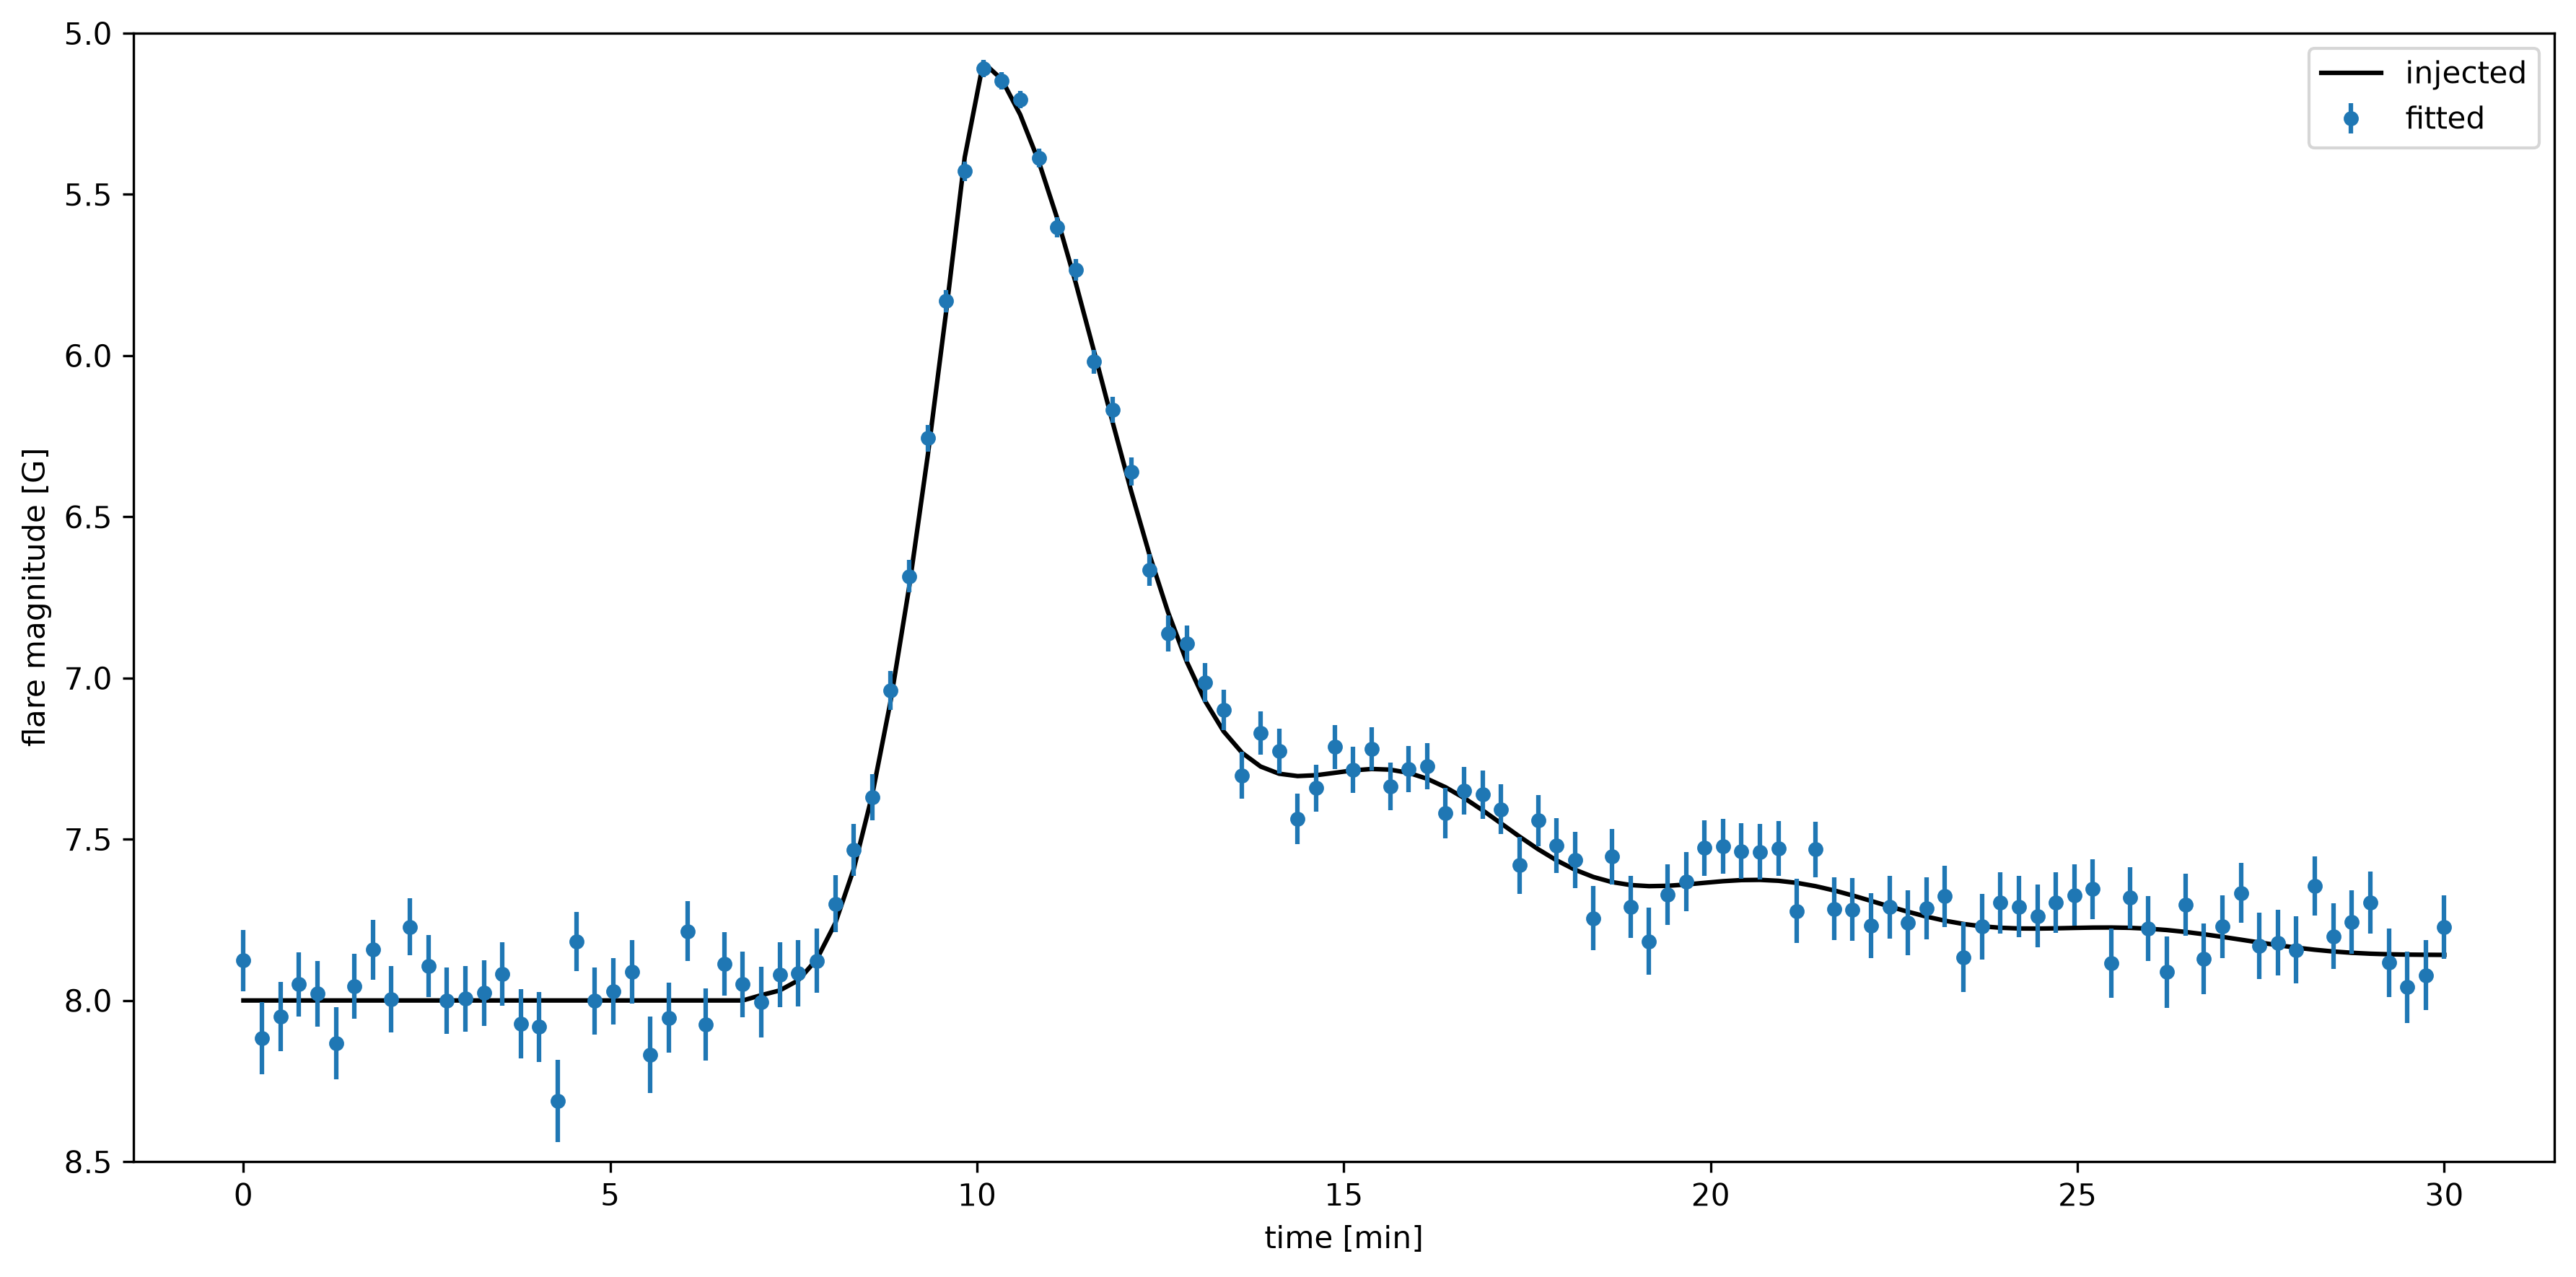

In [39]:
recovered = np.asarray(fitted.sources["flare"].brightness.value)
sigma = np.asarray(errors.sources["flare"].brightness.value)

fitted_mag = REF_MAG - 2.5 * np.log10(np.clip(recovered, 1e-12, None))
sigma_mag = 2.5 / np.log(10) * sigma / np.clip(recovered, 1e-12, None)

fig, ax = plt.subplots(figsize=(12, 6), dpi=300)
ax.plot(minutes, REF_MAG-flare, "k-", label="injected")
ax.errorbar(minutes, fitted_mag, yerr=sigma_mag, fmt="o", ms=4, label="fitted")
ax.invert_yaxis()
ax.set_ylim(8.5, 5)
ax.set_xlabel("time [min]")
ax.set_ylabel("flare magnitude [G]")
ax.legend()
plt.tight_layout()

The nuisances came out with it. The fitted pointing tracks the injected systematic offset,
drift and jitter, and the fitted pixel efficiencies reproduce the injected flat field times
the throughput we deliberately left frozen.

pointing residual rms: [2.1 2.3] arcsec
flat field residual rms: 0.28%
airglow: 100.1 sfu (injected 100)


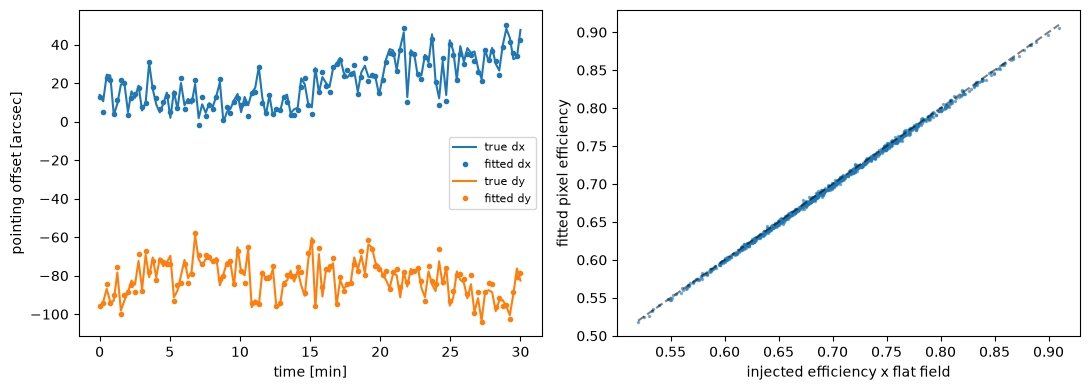

In [33]:
shift_fit = np.rad2deg(np.asarray(fitted.instrument.shift.value)) * 3600
shift_true = np.rad2deg(np.asarray(truth.instrument.shift.value)) * 3600

flat_true = np.asarray(truth.instrument.pixel_efficiency.value * truth.instrument.efficiency.value)
flat_fit = np.asarray(fitted.instrument.pixel_efficiency.value)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for k, name in enumerate("xy"):
    axes[0].plot(minutes, shift_true[:, k], "-", color=f"C{k}", label=f"true d{name}")
    axes[0].plot(minutes, shift_fit[:, k], ".", color=f"C{k}", label=f"fitted d{name}")
axes[0].set_xlabel("time [min]")
axes[0].set_ylabel("pointing offset [arcsec]")
axes[0].legend(fontsize=8)

axes[1].plot(flat_true, flat_fit, ".", ms=3, alpha=0.5)
lims = [flat_true.min(), flat_true.max()]
axes[1].plot(lims, lims, "k--", alpha=0.5)
axes[1].set_xlabel("injected efficiency x flat field")
axes[1].set_ylabel("fitted pixel efficiency")
plt.tight_layout()

print(f"pointing residual rms: {np.std(shift_fit - shift_true, axis=0).round(1)} arcsec")
print(f"flat field residual rms: {np.std(flat_fit / flat_true - 1):.2%}")

# The airglow level trades against the mean of the flat field, so it lands close to
# the injected 100 sfu rather than on it.
print(f"airglow: {float(fitted.airglow.spectral_model.params.value):.1f} sfu (injected 100)")